# Assignment 1
Matthew Koh
OPIM 5641 - Business Decision Modeling 
9/20/2026 10:59 PM 😭

## Dataset: FronkonGames, "Steam Games Dataset" (Kaggle/Hugging Face)
snapshot 2026-08-01, accessed 2026-08-04
cleaned by Matthew Koh for OPIM 5501 Visual Analytics, Project 2, Group 7 (Summer 2026)

the dataset's reviews for new games drops off in May 2025, because at the time of the snapshot reviews were not yet populated. so I cut the dataset there.

## AI assist
used Claude to structure work distribution, analysis, choices, and interpretation will be mine

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/mkoh55/opim5641-work/main/Assignment%201/steam_clean_master.csv'
df = pd.read_csv(url)
print(df.shape)
df.head(3)

(93432, 38)


,AppID,Name,ReleaseDate,ReleaseYear,Price,Discount,DLCCount,RequiredAge,EstimatedOwners,OwnersMin,...,PublisherCount,Genres,GenreCount,Categories,TopTag,TopTagVotes,TagCount,Tags,LanguageCount,FullAudioLanguageCount
0,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,2016,5.24,65,0,0,0 - 20000,0,...,1,Adventure,1,Single-player;Steam Trading Cards;Steam Cloud;...,Adventure,27.0,4,Adventure;Visual Novel;Anime;Cute,1,0
1,1034400,Mystery Solitaire The Black Raven,2019-05-06,2019,4.99,0,0,0,0 - 20000,0,...,1,Casual,1,Single-player;Family Sharing,Casual,83.0,16,Casual;Card Game;Solitaire;Puzzle;Hidden Objec...,4,0
2,3292190,버튜버 파라노이아 - Vtuber Paranoia,2024-10-31,2024,8.99,0,1,0,0 - 20000,0,...,1,Casual;Indie;Simulation,3,Single-player;Steam Achievements;Family Sharing,NaN,NaN,0,NaN,1,1


## Initial Description

In [2]:
pd.set_option('display.float_format', '{:,.2f}'.format)

In [3]:
df[['Price','TotalReviews']].describe()

,Price,TotalReviews
count,"93,432.00","93,432.00"
mean,5.13,"1,583.92"
std,12.00,"37,373.84"
min,0.00,0.00
25%,0.99,3.00
50%,2.99,17.00
75%,5.99,93.00
max,999.98,"8,815,087.00"


## Initial Description finding
both price and review are right skewed
review count is VERY right skewed - median game has 17 reviews, mean is 1,584

can't summarize this column with average, normal distribution model won't work for anything built on the reviews problem. taking the log of totalreviews can help

## Log 10 Histogram

lots of games on steam have no reviews. 10,993 games had no reviews, dropped


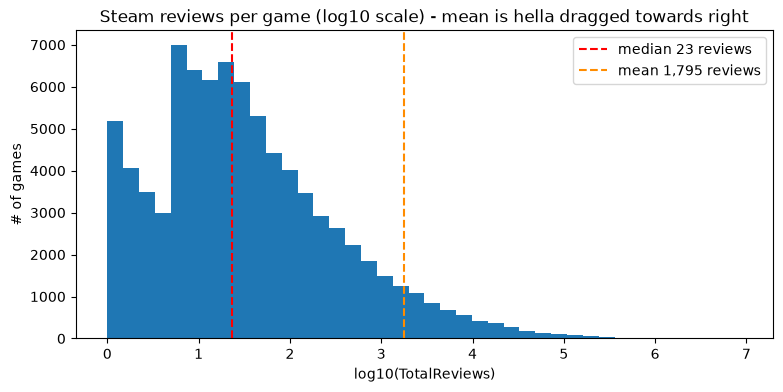

In [4]:
import numpy as np

reviewed = df[df['TotalReviews'] > 0]['TotalReviews'] # (np.log10(0) is negative infinity)
print(f'lots of games on steam have no reviews. {(df["TotalReviews"] == 0).sum():,} games had no reviews, dropped')

plt.figure(figsize=(9, 4))
plt.hist(np.log10(reviewed), bins=40) # 10 bins isn't enough to see the crazy tail


plt.axvline(np.log10(reviewed.median()), 
            color='red', 
            linestyle='dashed', 
            label=f'median {reviewed.median():,.0f} reviews')
plt.axvline(np.log10(reviewed.mean()), 
            color='darkorange', 
            linestyle='dashed', 
            label=f'mean {reviewed.mean():,.0f} reviews')

plt.legend()
plt.title('Steam reviews per game (log10 scale) - mean is hella dragged towards right')
plt.xlabel('log10(TotalReviews)')
plt.ylabel('# of games')

plt.savefig('fig1.png')

 ## log(10) Histogram findings 
typical reviewed game has 23 reviews, while mean of 1795 is almost 100x that

2% of the dataset has >10k reviews: 2% of the dataset has more reviews than the other 98%

Text(0, 0.5, 'number of games')

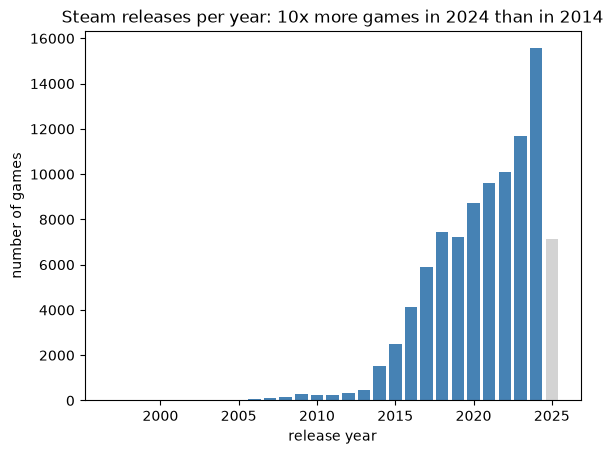

In [5]:
counts = df['ReleaseYear'].value_counts().sort_index()#.plot(kind='bar') # order by index sorts by time, don't want to sort by count
colors = ['lightgray' if year == 2025 else 'steelblue' for year in counts.index]

plt.bar(counts.index, counts.values, color=colors)
plt.title('Steam releases per year: 10x more games in 2024 than in 2014')
plt.xlabel('release year')
plt.ylabel('number of games')


## Bar chart finding
release crowding exploded around 2016, 2025 is partial for the reason explained at the top

flood of supply is the life of an indie game dev. good luck getting enough reviews to even get rated

## FRED (Federal Reserve Economic Data): Free public db
https://fred.stlouisfed.org/

In [6]:
cpi = pd.read_csv('https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL')
cpi.columns = ['date','cpi']
# print(cpi.describe())
cpi['year'] = pd.to_datetime(cpi['date']).dt.year
annual = cpi.groupby('year')['cpi'].mean().reset_index()
base = annual.loc[annual.year==2025,'cpi'].values[0]
annual['deflator'] = base / annual['cpi']
df = df.merge(annual[['year','deflator']], left_on='ReleaseYear', right_on='year', how='left') # only works once, reset to rerun
df['RealPrice'] = df['Price'] * df['deflator']

## probably not worth pursuing
deflating by releaseyear assumes price is what the game cost when it launched, when I don't think that's the case here. trying to deflate a 2015 game's price in 2025 shouldn't produce anything that makes sense

In [19]:
import requests, io
url = 'https://en.wikipedia.org/wiki/List_of_best-selling_PC_games'
response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0 (OPIM 5641 student project)'}) 
# print(response.status_code) # 200, nice
tables = pd.read_html(io.StringIO(response.text))
# for i, t in enumerate(tables): print(i, list(t.columns)[:4]) # table where
wiki = tables[1]
wiki['WikiSalesM'] = wiki['Total copies sold'].str.extract(r'([\d.]+)').astype(float)

# clean and parse

def clean(s):
    return (s.str.replace('™','', regex=False).str.replace('®','', regex=False)
            .str.strip().str.lower())
tmp = df[['Name','TotalReviews']].copy()
tmp['key'] = clean(tmp['Name'])
wiki['key'] = clean(wiki['Game'].astype(str))
# print('uhh: ', wiki)# nice

200
